# Phase 2 — Data Processing (Days 2-3)

**Goal:** (1) Tile every downloaded .svs slide into 512×512 patches with Reinhard
normalization. (2) Compute RNA-seq ground-truth labels: CD274 expression, immune
gene set scores, immune phenotype, immune score.

**Outputs:**
- `data/processed/patches/{slide_id}/` — 512×512 JPEG patches per slide
- `data/signatures/immune_signatures.csv` — Per-patient immune labels

---
**Hard Rules:**
- Patch size: **512×512** at 20× magnification (~0.5 µm/px)
- Stain normalization: **Reinhard** (LAB color space, NOT Macenko)
- Tissue threshold: **≥50%** tissue content per patch
- CD274 expression: log2(TPM+1) → **median split** → high/low
- TME subtypes: IE, IE/F, F, D (slash notation)
- MSI-L → treated as MSS (clinical convention)

## Colab setup

In [1]:


import os

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/ImmunoPath"
DATA_DIR = f"{PROJECT_DIR}/data"

# Create processing output directories
for d in [
    f"{DATA_DIR}/processed/patches",
    f"{DATA_DIR}/signatures",
]:
    os.makedirs(d, exist_ok=True)

print(f"Directories ready")
print(f"   Input slides:  {DATA_DIR}/raw/slides/")
print(f"   Input RNA-seq: {DATA_DIR}/raw/rnaseq/")
print(f"   Output patches: {DATA_DIR}/processed/patches/")
print(f"   Output sigs:    {DATA_DIR}/signatures/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directories ready
   Input slides:  /content/drive/MyDrive/ImmunoPath/data/raw/slides/
   Input RNA-seq: /content/drive/MyDrive/ImmunoPath/data/raw/rnaseq/
   Output patches: /content/drive/MyDrive/ImmunoPath/data/processed/patches/
   Output sigs:    /content/drive/MyDrive/ImmunoPath/data/signatures/


## Install dependancies


In [2]:

# OpenSlide needs system-level install on Linux (Colab)

import subprocess
subprocess.run(["apt-get", "install", "-y", "-qq", "openslide-tools"], check=True)
subprocess.run(["pip", "install", "-q", "openslide-python", "opencv-python-headless",
                 "Pillow", "numpy", "pandas", "scipy", "tqdm", "scikit-learn"], check=True)

# Verify imports
import openslide
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from scipy import stats
from tqdm.auto import tqdm
import json
import gc
from pathlib import Path
import glob

print(f"OpenSlide version: {openslide.__version__}")
print(f"All dependencies loaded")

OpenSlide version: 1.4.3
All dependencies loaded


## Reinhard Stain Normalization

In [3]:
REF_MEANS = np.array([148.60, 169.30, 105.97])
REF_STDS  = np.array([ 41.56,   9.01,  14.67])

def reinhard_normalize(image_rgb: np.ndarray,
                       ref_means: np.ndarray = REF_MEANS,
                       ref_stds: np.ndarray = REF_STDS) -> np.ndarray:
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    src_means = np.mean(lab, axis=(0, 1))
    src_stds = np.std(lab, axis=(0, 1))

    # Vectorized transfer (no per-channel loop)
    scale = np.where(src_stds > 1e-6, ref_stds / src_stds, 1.0)
    lab = (lab - src_means) * scale + ref_means

    lab = np.clip(lab, 0, 255).astype(np.uint8)
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

print("Reinhard normalization ready (vectorized)")


Reinhard normalization ready (vectorized)


## Tissue Detection Functions

In [4]:

# Detect tissue regions in H&E patches using Otsu thresholding.
# Filter out background, pen marks, and artifacts.
MORPH_KERNEL_5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

def compute_tissue_mask(image_rgb: np.ndarray, threshold: int = 220) -> np.ndarray:
    """
    Create a binary tissue mask using grayscale thresholding.

    Tissue appears darker than background in H&E slides.
    Background is usually white/near-white (>220 in grayscale).

    Args:
        image_rgb: RGB image as numpy array
        threshold: Grayscale threshold (pixels < threshold = tissue)

    Returns:
        Binary mask (1 = tissue, 0 = background)
    """
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    # Tissue is darker than background
    mask = (gray < threshold).astype(np.uint8)

    # Morphological cleanup (remove small holes and noise)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, MORPH_KERNEL_5, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, MORPH_KERNEL_5, iterations=1)

    return mask


def compute_tissue_fraction(image_rgb: np.ndarray, threshold: int = 220) -> float:
    """Compute fraction of tissue (non-background) pixels."""
    mask = compute_tissue_mask(image_rgb, threshold)
    return cv2.countNonZero(mask) / float(mask.size)


def is_pen_mark(image_rgb: np.ndarray) -> bool:
    """
    Detect pen marks (common artifacts in TCGA slides).
    Pen marks are typically blue, green, or black ink.
    """
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

    # Blue pen: high saturation, low value, hue in blue range
    blue_mask = ((hsv[:, :, 0] > 90) & (hsv[:, :, 0] < 130) &
                 (hsv[:, :, 1] > 50) & (hsv[:, :, 2] < 200))

    # Green pen
    green_mask = ((hsv[:, :, 0] > 35) & (hsv[:, :, 0] < 85) &
                  (hsv[:, :, 1] > 50) & (hsv[:, :, 2] < 200))

    # Black pen / very dark artifacts
    black_mask = (hsv[:, :, 2] < 40)

    pen_pixels = np.count_nonzero(blue_mask) + np.count_nonzero(green_mask) + np.count_nonzero(black_mask)
    pen_fraction = pen_pixels / float(image_rgb.shape[0] * image_rgb.shape[1])
    return pen_fraction > 0.1  # >10% pen pixels → reject


def is_blurry(image_rgb: np.ndarray, threshold: float = 50.0) -> bool:
    """Detect blurry patches using Laplacian variance."""
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    return laplacian_var < threshold


print("Tissue detection functions defined")

Tissue detection functions defined


## WSI Patch Extraction Pipeline

In [5]:
PATCH_SIZE = 512
TARGET_MPP = 0.5
TISSUE_THRESHOLD = 0.5
MAX_PATCHES_PER_SLIDE = 64
JPEG_QUALITY = 95


def get_slide_mpp(slide: openslide.OpenSlide) -> float:
    try:
        mpp_x = float(slide.properties.get(openslide.PROPERTY_NAME_MPP_X, 0))
        if mpp_x > 0:
            return mpp_x
    except (ValueError, KeyError):
        pass
    try:
        power = float(slide.properties.get(openslide.PROPERTY_NAME_OBJECTIVE_POWER, 0))
        if power > 0:
            return 10.0 / power
    except (ValueError, KeyError):
        pass
    return 0.25


THUMB_KERNEL_5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

def get_tissue_mask_from_thumbnail(slide, thumb_size=512):
    """Build a tissue mask from the low-res thumbnail to skip empty regions."""
    thumb = slide.get_thumbnail((thumb_size, thumb_size))
    thumb_rgb = np.array(thumb.convert("RGB"))
    gray = cv2.cvtColor(thumb_rgb, cv2.COLOR_RGB2GRAY)
    mask = (gray < 220).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, THUMB_KERNEL_5, iterations=2)
    return mask, thumb_rgb.shape[1], thumb_rgb.shape[0]


def get_slide_bounds(slide: openslide.OpenSlide):
    """Use OpenSlide tissue bounds when available to avoid scanning blank margins."""
    width_l0, height_l0 = slide.dimensions
    props = slide.properties
    bounds_x_key = getattr(openslide, "PROPERTY_NAME_BOUNDS_X", "openslide.bounds-x")
    bounds_y_key = getattr(openslide, "PROPERTY_NAME_BOUNDS_Y", "openslide.bounds-y")
    bounds_w_key = getattr(openslide, "PROPERTY_NAME_BOUNDS_WIDTH", "openslide.bounds-width")
    bounds_h_key = getattr(openslide, "PROPERTY_NAME_BOUNDS_HEIGHT", "openslide.bounds-height")
    try:
        bx = int(float(props.get(bounds_x_key, 0)))
        by = int(float(props.get(bounds_y_key, 0)))
        bw = int(float(props.get(bounds_w_key, width_l0)))
        bh = int(float(props.get(bounds_h_key, height_l0)))
    except Exception:
        return 0, 0, width_l0, height_l0
    if bw <= 0 or bh <= 0:
        return 0, 0, width_l0, height_l0
    bx = max(0, min(bx, width_l0 - 1))
    by = max(0, min(by, height_l0 - 1))
    bw = min(bw, width_l0 - bx)
    bh = min(bh, height_l0 - by)
    return bx, by, bw, bh


def extract_patches_from_slide(
    slide_path: str,
    output_dir: str,
    patch_size: int = PATCH_SIZE,
    target_mpp: float = TARGET_MPP,
    tissue_threshold: float = TISSUE_THRESHOLD,
    max_patches: int = MAX_PATCHES_PER_SLIDE,
    normalize: bool = True,
    jpeg_quality: int = JPEG_QUALITY,
) -> dict:
    slide = openslide.OpenSlide(slide_path)
    try:
        slide_id = Path(slide_path).stem
        slide_mpp = get_slide_mpp(slide)
        downsample_factor = target_mpp / slide_mpp if slide_mpp > 0 else 1.0

        best_level = slide.get_best_level_for_downsample(max(downsample_factor, 1.0))
        level_ds = float(slide.level_downsamples[best_level])
        patch_size_l0 = int(patch_size * level_ds)
        width_l0, height_l0 = slide.dimensions
        bounds_x, bounds_y, bounds_w, bounds_h = get_slide_bounds(slide)

        patch_dir = os.path.join(output_dir, slide_id)
        os.makedirs(patch_dir, exist_ok=True)

        # Thumbnail-based tissue pre-filter (skip empty grid cells)
        tissue_mask, tw, th = get_tissue_mask_from_thumbnail(slide)
        scale_x = tw / width_l0
        scale_y = th / height_l0

        x_stop = bounds_x + bounds_w - patch_size_l0 + 1
        y_stop = bounds_y + bounds_h - patch_size_l0 + 1

        all_candidates = []
        if x_stop > bounds_x and y_stop > bounds_y:
            xs = np.arange(bounds_x, x_stop, patch_size_l0, dtype=np.int32)
            ys = np.arange(bounds_y, y_stop, patch_size_l0, dtype=np.int32)
            if xs.size > 0 and ys.size > 0:
                tx = np.clip(((xs + (patch_size_l0 // 2)) * scale_x).astype(np.int32), 0, tw - 1)
                ty = np.clip(((ys + (patch_size_l0 // 2)) * scale_y).astype(np.int32), 0, th - 1)
                tx_grid, ty_grid = np.meshgrid(tx, ty)
                x_grid, y_grid = np.meshgrid(xs, ys)
                keep = tissue_mask[ty_grid, tx_grid] > 0
                all_candidates = np.column_stack((x_grid[keep], y_grid[keep])).tolist()

        np.random.shuffle(all_candidates)

        patches_metadata = []
        extracted = 0
        for x, y in all_candidates:
            if extracted >= max_patches:
                break
            try:
                patch = slide.read_region((x, y), best_level, (patch_size, patch_size))
                patch_rgb = np.array(patch.convert('RGB'))
                patch.close()

                tissue_frac = compute_tissue_fraction(patch_rgb)
                if tissue_frac < tissue_threshold:
                    continue
                if is_pen_mark(patch_rgb):
                    continue
                if is_blurry(patch_rgb):
                    continue
                if normalize:
                    patch_rgb = reinhard_normalize(patch_rgb)

                patch_name = f"{slide_id}_patch_{extracted:03d}.jpg"
                patch_path = os.path.join(patch_dir, patch_name)
                patch_bgr = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2BGR)
                write_ok = cv2.imwrite(
                    patch_path,
                    patch_bgr,
                    [int(cv2.IMWRITE_JPEG_QUALITY), int(jpeg_quality)],
                )
                if not write_ok:
                    raise RuntimeError(f"Failed to write patch: {patch_path}")

                patches_metadata.append({
                    "patch_name": patch_name, "x": x, "y": y,
                    "level": best_level, "tissue_fraction": round(tissue_frac, 3),
                })
                extracted += 1
            except Exception:
                continue

        metadata = {
            "slide_id": slide_id, "slide_path": slide_path,
            "slide_mpp": slide_mpp, "extraction_level": best_level,
            "level_downsample": level_ds, "patch_size": patch_size,
            "target_mpp": target_mpp,
            "total_candidates": len(all_candidates),
            "scan_bounds_l0": [int(bounds_x), int(bounds_y), int(bounds_w), int(bounds_h)],
            "patches_extracted": extracted, "normalized": normalize,
            "patches": patches_metadata,
        }
        meta_path = os.path.join(patch_dir, f"{slide_id}_metadata.json")
        with open(meta_path, 'w') as f:
            json.dump(metadata, f, indent=2)
        return metadata
    finally:
        slide.close()
        gc.collect()


print("Patch extraction pipeline ready")
print(f"   {PATCH_SIZE}x{PATCH_SIZE} at {TARGET_MPP} um/px, thumbnail pre-filter enabled")
print(f"   Tissue threshold: {TISSUE_THRESHOLD}, max patches: {MAX_PATCHES_PER_SLIDE}")


Patch extraction pipeline ready
   512x512 at 0.5 um/px, thumbnail pre-filter enabled
   Tissue threshold: 0.5, max patches: 64


## Run Patch Extraction on Downloaded Slides

In [6]:
import pandas as pd

slides_csv = f"{DATA_DIR}/raw/manifests/slide_metadata.csv"
slides_df = pd.read_csv(slides_csv)

print("Loaded slide metadata:", slides_df.shape)


Loaded slide metadata: (1053, 6)


In [14]:
!wget -q https://gdc.cancer.gov/files/public/file/gdc-client_v1.6.1_Ubuntu_x64.zip
!unzip -q gdc-client_v1.6.1_Ubuntu_x64.zip
!chmod +x gdc-client


In [15]:
from pathlib import Path

slide_dir = f"{DATA_DIR}/raw/slides"

existing = {Path(p).name for p in Path(slide_dir).glob("*.svs")}
missing = slides_df[~slides_df["file_name"].isin(existing)]

manifest_path = "/content/missing_manifest.txt"
missing[["file_id", "file_name"]].to_csv(
    manifest_path,
    sep="\t",
    index=False
)

print("Slides to download:", len(missing))
print("Manifest created at:", manifest_path)


Slides to download: 108
Manifest created at: /content/missing_manifest.txt


In [19]:
import requests
import json
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

GDC_FILES_ENDPOINT = "https://api.gdc.cancer.gov/files"

file_ids = slides_df["file_id"].tolist()

def fetch_batch(batch_ids):
    filters = {
        "op": "in",
        "content": {
            "field": "file_id",
            "value": batch_ids
        }
    }

    payload = {
        "filters": filters,
        "fields": "file_id,file_name,file_size,md5sum,state",
        "format": "JSON",
        "size": len(batch_ids)
    }

    r = requests.post(GDC_FILES_ENDPOINT, json=payload, timeout=60)
    r.raise_for_status()
    return r.json()["data"]["hits"]

all_hits = []
batch_size = 200

for i in tqdm(range(0, len(file_ids), batch_size)):
    batch = file_ids[i:i+batch_size]
    hits = fetch_batch(batch)
    all_hits.extend(hits)

manifest_df = pd.DataFrame([{
    "id": h["file_id"],
    "filename": h["file_name"],
    "md5": h["md5sum"],
    "size": h["file_size"],
    "state": h["state"]
} for h in all_hits])

slide_dir = f"{DATA_DIR}/raw/slides"
existing = {p.name for p in Path(slide_dir).glob("*.svs")}

manifest_missing = manifest_df[~manifest_df["filename"].isin(existing)]

manifest_path = "/content/missing_manifest.txt"
manifest_missing.to_csv(manifest_path, sep="\t", index=False)

print("Slides to download:", len(manifest_missing))
print("Manifest saved to:", manifest_path)


  0%|          | 0/6 [00:00<?, ?it/s]

Slides to download: 108
Manifest saved to: /content/missing_manifest.txt


In [20]:
!./gdc-client download -m /content/missing_manifest.txt -d "$DATA_DIR/raw/slides" -n 8


100% [#############################################] Time:  0:00:16  67.5 MiB/s 
100% [#############################################] Time:  0:00:28  61.7 MiB/s 
100% [#############################################] Time:  0:00:09  60.3 MiB/s 
100% [#############################################] Time:  0:00:14  55.7 MiB/s 
100% [#############################################] Time:  0:00:06  53.0 MiB/s 
100% [#############################################] Time:  0:00:15  61.1 MiB/s 
100% [#############################################] Time:  0:00:10  57.0 MiB/s 
100% [#############################################] Time:  0:00:26  69.5 MiB/s 
100% [#############################################] Time:  0:00:02  35.4 MiB/s 
100% [#############################################] Time:  0:00:13  52.5 MiB/s 
100% [#############################################] Time:  0:00:13  69.7 MiB/s 
100% [#############################################] Time:  0:00:07  63.8 MiB/s 
100% [######################

In [33]:
import os, shutil
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.auto import tqdm
import openslide

slide_dir = Path(f"{DATA_DIR}/raw/slides")
drive_patch_dir = Path(f"{DATA_DIR}/processed/patches")
local_tmp_root = Path("/content/tmp_slide")

drive_patch_dir.mkdir(parents=True, exist_ok=True)

def _find_processed_slide_ids(root_dir):
    processed = set()
    for meta_path in Path(root_dir).rglob("*_metadata.json"):
        processed.add(meta_path.parent.name)
    return processed

unsupported = {
    "TCGA-33-4532-01Z-00-DX2.cd6e3f47-14fd-46e4-baf8-2e682ade44d1"
}

svs_files = list(slide_dir.glob("*.svs"))
svs_ids = {p.stem for p in svs_files}
processed_ids = _find_processed_slide_ids(drive_patch_dir)

pending_ids = sorted(svs_ids - processed_ids - unsupported)

print(f"Total slides on disk: {len(svs_ids)}")
print(f"Already processed: {len(processed_ids)}")
print(f"Pending extraction: {len(pending_ids)}")

MAX_WORKERS = min(3, os.cpu_count() or 2)

def process_slide(slide_name):

    svs_path = slide_dir / f"{slide_name}.svs"
    slide_local_root = local_tmp_root / slide_name
    slide_drive_out = drive_patch_dir / slide_name

    try:
        slide = openslide.OpenSlide(str(svs_path))
        slide.close()
    except:
        return slide_name, "unsupported"

    try:
        if slide_local_root.exists():
            shutil.rmtree(slide_local_root)
        slide_local_root.mkdir(parents=True, exist_ok=True)

        meta = extract_patches_from_slide(
            slide_path=str(svs_path),
            output_dir=str(slide_local_root),
            patch_size=PATCH_SIZE,
            target_mpp=TARGET_MPP,
            tissue_threshold=TISSUE_THRESHOLD,
            max_patches=MAX_PATCHES_PER_SLIDE,
            normalize=True,
        )

        if slide_drive_out.exists():
            shutil.rmtree(slide_drive_out)
        shutil.move(str(slide_local_root), str(slide_drive_out))

        return slide_name, meta

    except Exception as e:
        return slide_name, str(e)

new_results = []
failed = []

with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(process_slide, s): s for s in pending_ids}

    for future in tqdm(as_completed(futures), total=len(futures)):
        slide_name, result = future.result()

        if result == "unsupported":
            failed.append(slide_name)
        elif isinstance(result, dict):
            new_results.append(result)
        else:
            failed.append(slide_name)

total_new_patches = sum(int(r.get("patches_extracted", 0)) for r in new_results)

print("\nEXTRACTION SUMMARY")
print(f"Newly processed: {len(new_results)}")
print(f"Failed: {len(failed)}")
print(f"New patches: {total_new_patches}")

if failed:
    print("\nFailed slides:")
    for sid in failed:
        print(sid)


Total slides on disk: 1053
Already processed: 953
Pending extraction: 107


  0%|          | 0/107 [00:00<?, ?it/s]


EXTRACTION SUMMARY
Newly processed: 107
Failed: 0
New patches: 6848


## Diversity-Based Patch Selection (K-Means)

In [34]:
import os, glob, json, time, random
import numpy as np
from tqdm.auto import tqdm
from sklearn.cluster import KMeans
from concurrent.futures import ThreadPoolExecutor, as_completed

N_SELECT = 8
WRITE_PER_SLIDE_JSON = True

if "patch_output_dir" not in globals():
    patch_output_dir = f"{DATA_DIR}/processed/patches"

SELECTION_WORKERS = min(4, max(1, (os.cpu_count() or 4) // 2))
if patch_output_dir.startswith("/content/drive"):
    SELECTION_WORKERS = min(SELECTION_WORKERS, 2)

# Optional override for quick tuning without editing notebook.
SELECTION_WORKERS = int(os.environ.get("PHASE2_SELECTION_WORKERS", SELECTION_WORKERS))
SELECTION_WORKERS = max(1, SELECTION_WORKERS)

# Local SSD cache avoids repeated work and reduces Drive churn.
LOCAL_CACHE_DIR = "/tmp/immunopath_selection"
os.makedirs(LOCAL_CACHE_DIR, exist_ok=True)


def _safe_write_json(payload: dict, target_path: str) -> bool:
    """Atomic JSON write with graceful fallback on Drive I/O errors."""
    tmp_path = f"{target_path}.tmp"
    try:
        with open(tmp_path, "w") as f:
            json.dump(payload, f, indent=2)
        os.replace(tmp_path, target_path)
        return True
    except OSError:
        try:
            if os.path.exists(tmp_path):
                os.remove(tmp_path)
        except Exception:
            pass
        return False


def _safe_read_json(path: str, retries: int = 3, base_sleep: float = 0.2):
    """Read JSON with retry/backoff for transient Drive I/O errors."""
    for attempt in range(retries):
        try:
            with open(path) as f:
                return json.load(f)
        except OSError as err:
            if attempt == retries - 1:
                break
            sleep_s = base_sleep * (2 ** attempt) + random.uniform(0.0, 0.15)
            time.sleep(sleep_s)
        except Exception:
            return None
    return None


def _list_patch_names(slide_dir: str) -> list:
    """Single-pass listing to avoid many per-file Drive stat calls."""
    names = []
    try:
        for entry in os.scandir(slide_dir):
            if entry.name.endswith(".jpg"):
                names.append(entry.name)
    except OSError:
        return []
    names.sort()
    return names


def _select_farthest(features: np.ndarray, selected: list, target_n: int) -> list:
    """Fill selection via greedy farthest-point sampling."""
    n = features.shape[0]
    if n == 0:
        return []

    selected = list(dict.fromkeys(int(i) for i in selected if 0 <= int(i) < n))
    if not selected:
        selected = [0]

    used = np.zeros(n, dtype=bool)
    used[selected] = True

    while len(selected) < target_n:
        remaining = np.where(~used)[0]
        if remaining.size == 0:
            break
        d = np.linalg.norm(
            features[remaining, None, :] - features[np.array(selected)][None, :, :],
            axis=2,
        )
        min_d = d.min(axis=1)
        next_idx = int(remaining[np.argmax(min_d)])
        selected.append(next_idx)
        used[next_idx] = True

    return selected[:target_n]


def _features_from_metadata(meta: dict):
    """Use metadata (x, y, tissue_fraction) to avoid opening every JPEG from Drive."""
    rows = meta.get("patches", []) if isinstance(meta, dict) else []
    patch_names = []
    features = []

    for row in rows:
        patch_name = row.get("patch_name")
        if not patch_name:
            continue
        patch_names.append(patch_name)
        features.append([
            float(row.get("x", 0.0)),
            float(row.get("y", 0.0)),
            float(row.get("tissue_fraction", 0.0)),
        ])

    if not features:
        return [], np.empty((0, 3), dtype=np.float32)

    features = np.asarray(features, dtype=np.float32)
    mins = features.min(axis=0)
    spans = np.maximum(features.max(axis=0) - mins, 1e-6)
    features = (features - mins) / spans
    return patch_names, features


def select_diverse_patches(slide_dir: str, n_select: int = N_SELECT) -> dict:
    """Drive-safe patch selection with metadata-first strategy.

    This avoids opening every patch JPEG (which often trips Drive I/O quota).
    """
    slide_id = os.path.basename(slide_dir)
    cache_path = os.path.join(LOCAL_CACHE_DIR, f"{slide_id}_selected_{n_select}.json")
    meta_path = os.path.join(slide_dir, f"{slide_id}_metadata.json")
    per_slide_path = os.path.join(slide_dir, f"{slide_id}_selected_8.json")

    if os.path.exists(cache_path):
        cached = _safe_read_json(cache_path, retries=2)
        if isinstance(cached, dict):
            cached_selected = cached.get("selected", [])
            if cached_selected:
                return {
                    "slide_id": slide_id,
                    "n_patches": int(cached.get("n_total", len(cached_selected))),
                    "selected": cached_selected[:n_select],
                    "method": cached.get("method", "cached_local"),
                }

    patch_names = []
    features = np.empty((0, 3), dtype=np.float32)
    if os.path.exists(meta_path):
        meta = _safe_read_json(meta_path, retries=4)
        if isinstance(meta, dict):
            patch_names, features = _features_from_metadata(meta)

    if not patch_names:
        patch_names = _list_patch_names(slide_dir)

    n_total = len(patch_names)
    if n_total == 0:
        return {"slide_id": slide_id, "n_patches": 0, "selected": [], "method": "none"}

    target_n = min(n_select, n_total)
    selected = []
    method = "fallback_filename_order"
    n_unique_features = 0

    if len(patch_names) >= target_n and features.shape[0] >= target_n:
        unique_feats, unique_first_idx = np.unique(features.round(6), axis=0, return_index=True)
        n_unique_features = int(unique_feats.shape[0])

        if n_unique_features <= 1:
            step = max(1, len(patch_names) // target_n)
            seed = list(range(0, len(patch_names), step))[:target_n]
            picked = _select_farthest(features, seed, target_n)
            method = "uniform_xy_tissue"
        else:
            k = min(target_n, n_unique_features)
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=3, max_iter=100)
            labels = kmeans.fit_predict(unique_feats)
            picked = []
            for cluster_id in range(k):
                cluster_mask = labels == cluster_id
                if not np.any(cluster_mask):
                    continue
                cluster_u_idx = np.where(cluster_mask)[0]
                centroid = kmeans.cluster_centers_[cluster_id]
                dists = np.linalg.norm(unique_feats[cluster_u_idx] - centroid, axis=1)
                best_u_idx = int(cluster_u_idx[np.argmin(dists)])
                picked.append(int(unique_first_idx[best_u_idx]))
            picked = _select_farthest(features, picked, target_n)
            method = "kmeans_xy_tissue"

        selected = [patch_names[i] for i in sorted(picked[:target_n])]

    if not selected:
        selected = patch_names[:target_n]

    # Validate selected names with a single directory scan (faster on Drive).
    existing_names = set(_list_patch_names(slide_dir))
    if existing_names:
        selected_existing = [name for name in selected if name in existing_names]
        if len(selected_existing) < target_n:
            existing_set = set(selected_existing)
            for name in patch_names:
                if name in existing_names and name not in existing_set:
                    selected_existing.append(name)
                    existing_set.add(name)
                if len(selected_existing) >= target_n:
                    break
        selected = selected_existing[:target_n]
    else:
        selected = selected[:target_n]

    result = {
        "slide_id": slide_id,
        "method": method,
        "n_total": n_total,
        "n_unique_features": n_unique_features,
        "n_selected": len(selected),
        "selected": selected,
    }
    _safe_write_json(result, cache_path)
    if WRITE_PER_SLIDE_JSON:
        _safe_write_json(result, per_slide_path)

    return {"slide_id": slide_id, "n_patches": n_total, "selected": selected, "method": method}


# ---------- RUN SELECTION ----------
print(f"Running diversity-based patch selection (K={N_SELECT})...")
print(f"  Workers: {SELECTION_WORKERS}")
print(f"  Strategy: metadata-first (Drive-safe)")

slide_dirs_for_selection = [
    os.path.join(patch_output_dir, d)
    for d in sorted(os.listdir(patch_output_dir))
    if os.path.isdir(os.path.join(patch_output_dir, d))
] if os.path.exists(patch_output_dir) else []

selection_results = []
with ThreadPoolExecutor(max_workers=SELECTION_WORKERS) as executor:
    futures = {executor.submit(select_diverse_patches, d): d for d in slide_dirs_for_selection}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Selecting patches"):
        selection_results.append(future.result())

manifest = {r["slide_id"]: r for r in selection_results if r.get("selected")}
manifest_path = os.path.join(patch_output_dir, "selection_manifest.json")
if not _safe_write_json(manifest, manifest_path):
    manifest_path = os.path.join(LOCAL_CACHE_DIR, "selection_manifest.json")
    _safe_write_json(manifest, manifest_path)

n_with_selection = sum(1 for r in selection_results if len(r.get("selected", [])) > 0)
method_counts = {}
for r in selection_results:
    m = r.get("method", "none")
    method_counts[m] = method_counts.get(m, 0) + 1

print(f"\nDiversity patch selection complete:")
print(f"   Slides processed: {len(selection_results)}")
print(f"   Slides with selected patches: {n_with_selection}")
print(f"   Selection methods: {method_counts}")
print(f"   Manifest: {manifest_path}")

Running diversity-based patch selection (K=8)...
  Workers: 2
  Strategy: metadata-first (Drive-safe)


Selecting patches:   0%|          | 0/1060 [00:00<?, ?it/s]


Diversity patch selection complete:
   Slides processed: 1060
   Slides with selected patches: 949
   Selection methods: {'kmeans_xy_tissue': 948, 'none': 111, 'uniform_xy_tissue': 1}
   Manifest: /content/drive/MyDrive/ImmunoPath/data/processed/patches/selection_manifest.json


## Visualise Sample Patches (QC Check)

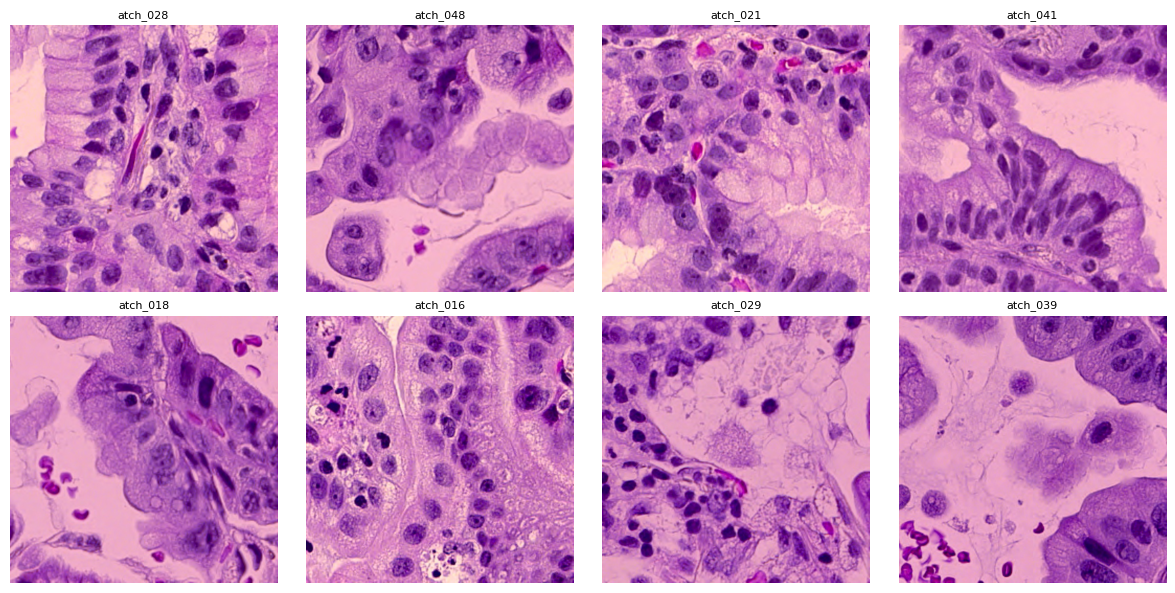

Saved QC image to: /content/patch_sample.png


In [35]:
import os
import glob
import shutil
import numpy as np
from pathlib import Path
from PIL import Image, ImageFile
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True

DRIVE_PATCH_DIR = "/content/drive/MyDrive/ImmunoPath/data/processed/patches"
LOCAL_PATCH_DIR = "/content/local_patches"
SAVE_PATH = "/content/patch_sample.png"

if os.path.exists(LOCAL_PATCH_DIR):
    shutil.rmtree(LOCAL_PATCH_DIR)

os.makedirs(LOCAL_PATCH_DIR, exist_ok=True)

slide_folders = [f.path for f in os.scandir(DRIVE_PATCH_DIR) if f.is_dir()]

if not slide_folders:
    print("No slide folders found.")
else:
    chosen_slide = np.random.choice(slide_folders)
    patch_files = glob.glob(os.path.join(chosen_slide, "*.jpg"))

    if not patch_files:
        print("No patches found in chosen slide.")
    else:
        selected = np.random.choice(patch_files, min(8, len(patch_files)), replace=False)

        for p in selected:
            shutil.copy2(p, LOCAL_PATCH_DIR)

        local_patches = glob.glob(os.path.join(LOCAL_PATCH_DIR, "*.jpg"))

        n_show = len(local_patches)
        n_cols = min(4, n_show)
        n_rows = int(np.ceil(n_show / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
        axes = np.atleast_1d(axes).flatten()

        for ax, patch_path in zip(axes, local_patches):
            with Image.open(patch_path) as img:
                ax.imshow(img.convert("RGB"))
            ax.set_title(Path(patch_path).stem[-8:], fontsize=8)
            ax.axis("off")

        for ax in axes[n_show:]:
            ax.axis("off")

        plt.tight_layout()
        plt.savefig(SAVE_PATH, dpi=150)
        plt.show()
        plt.close(fig)

        print("Saved QC image to:", SAVE_PATH)


---
## Part B: Compute Immune Signatures from RNA-seq

This section processes GDC RNA-seq files to compute:
1. **Gene set signature scores** (CD8, IFNγ, TIL, PD-L1 related, exhaustion)
2. **CD274 expression** → median split → high/low
3. **Immune phenotype** classification
4. **Composite immune score**



## Define Immune Gene Sets

In [36]:

# From spec Section 5.3 Step 2 (EXACT gene lists — do not modify)

IMMUNE_GENE_SETS = {
    "cd8_signature": [
        "CD8A", "CD8B", "GZMA", "GZMB", "PRF1", "IFNG", "CXCL9", "CXCL10"
    ],
    "ifng_signature": [
        "IFNG", "STAT1", "CCR5", "CXCL9", "CXCL10", "CXCL11", "IDO1",
        "PRF1", "GZMA", "HLA-DRA", "CXCR6", "LAG3", "NKG7", "PSMB10",
        "CMKLR1", "CD8A", "TIGIT", "PDCD1LG2"
    ],
    "til_signature": [
        "CD3D", "CD3E", "CD3G", "CD4", "CD8A", "CD8B", "FOXP3",
        "CD19", "MS4A1", "NCAM1"  # MS4A1=CD20, NCAM1=CD56
    ],
    "pdl1_related": [
        "CD274", "PDCD1", "PDCD1LG2", "CTLA4", "LAG3", "TIGIT", "HAVCR2"
    ],
    "exhaustion_signature": [
        "PDCD1", "CTLA4", "LAG3", "TIGIT", "HAVCR2", "TOX", "ENTPD1"
    ],
}

# CD274 is the gene encoding PD-L1 protein
# We use CD274 mRNA as a PROXY for PD-L1 IHC (NOT a replacement)
CD274_GENE = "CD274"

# Gene alias mapping (common issues with TCGA gene names)
GENE_ALIASES = {
    "CD20": "MS4A1",    # CD20 is commonly called MS4A1 in RNA-seq
    "CD56": "NCAM1",    # CD56 is NCAM1
    "PD-L1": "CD274",   # PD-L1 protein, CD274 gene
    "PD-1": "PDCD1",    # PD-1 protein, PDCD1 gene
    "TIM-3": "HAVCR2",  # TIM-3 protein, HAVCR2 gene
}

print("Immune gene sets defined:")
for name, genes in IMMUNE_GENE_SETS.items():
    print(f"   {name}: {len(genes)} genes")

Immune gene sets defined:
   cd8_signature: 8 genes
   ifng_signature: 18 genes
   til_signature: 10 genes
   pdl1_related: 7 genes
   exhaustion_signature: 7 genes


## Load RNA Seq Data

In [50]:
import os, shutil, tarfile
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed

bundle_path = "/content/drive/MyDrive/ImmunoPath/rnaseq_bundle.tar.gz"
local_bundle = "/content/rnaseq_bundle.tar.gz"
local_rnaseq_dir = Path("/content/local_rnaseq")

# Clean local state
if local_rnaseq_dir.exists():
    shutil.rmtree(local_rnaseq_dir)

if os.path.exists(local_bundle):
    os.remove(local_bundle)

# Copy bundle locally
print("Copying bundle locally...")
shutil.copy2(bundle_path, local_bundle)

# Extract locally
print("Extracting locally...")
with tarfile.open(local_bundle, "r:gz") as tar:
    tar.extractall(local_rnaseq_dir)

# RNA loading setup
USECOLS = [1, 6]
DTYPES = {1: "string", 6: "float32"}

def is_gzip_file(path: str) -> bool:
    return path.endswith(".gz")

import gzip

def load_gdc_rnaseq_fast(file_path: str) -> pd.Series:
    # Detect gzip by reading first 2 bytes
    with open(file_path, "rb") as f:
        magic = f.read(2)

    if magic == b"\x1f\x8b":
        compression = "gzip"
    else:
        compression = None

    df = pd.read_csv(
        file_path,
        sep="\t",
        compression=compression,
        usecols=USECOLS,
        dtype=DTYPES,
        engine="c",
        comment="#",
    )

    df.columns = ["gene", "tpm"]
    df = df[~df["gene"].fillna("").str.startswith("N_")]

    return df.groupby("gene", sort=False)["tpm"].max()


# Recursively collect files
local_files = list(local_rnaseq_dir.rglob("*.tsv*"))
print("RNA-seq files found:", len(local_files))

# Parallel loading
patient_tpm = {}

with ProcessPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(load_gdc_rnaseq_fast, str(f)): f for f in local_files}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Loading RNA-seq"):
        fpath = futures[future]
        sid = fpath.stem.replace(".tsv", "").replace(".gz", "")
        try:
            patient_tpm[sid] = future.result()
        except Exception as e:
            print("Failed:", sid, e)

# Build expression matrix
expression_matrix = (
    pd.concat(patient_tpm, axis=1, copy=False)
      .T
      .astype("float32")
)

print(f"Expression matrix: {expression_matrix.shape[0]} samples × {expression_matrix.shape[1]} genes")

# Log transform
expression_log2 = np.log2(expression_matrix + 1).astype("float32")

# Immune gene check
target_genes = set().union(*IMMUNE_GENE_SETS.values())
found_genes = target_genes & set(expression_matrix.columns)
missing_genes = target_genes - found_genes

print(f"Target immune genes found: {len(found_genes)}/{len(target_genes)}")
if missing_genes:
    print("Missing genes:", sorted(missing_genes))


Copying bundle locally...
Extracting locally...


/tmp/ipython-input-3548755417.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(local_rnaseq_dir)


RNA-seq files found: 950


Loading RNA-seq: 100%|██████████| 950/950 [00:24<00:00, 38.13it/s]


Expression matrix: 950 samples × 59427 genes
Target immune genes found: 34/34


## Compute Immune Signature Scores

In [51]:

# Method: Z-score each gene across all patients, then average within
# each gene set to get a single score per patient per signature.

def compute_signature_scores(expr_log2: pd.DataFrame,
                              gene_sets: dict) -> pd.DataFrame:
    """
    Compute immune signature scores from log2-TPM expression matrix.

    Method:
    1. Z-score normalize each gene across samples
    2. Average z-scores within each gene set
    3. Result: one score per patient per signature

    Args:
        expr_log2: DataFrame (patients × genes), log2(TPM+1)
        gene_sets: Dict mapping signature_name → list of gene symbols

    Returns:
        DataFrame (patients × signatures)
    """
    # Vectorized z-score across patients (matches scipy.stats.zscore, ddof=0)
    gene_means = expr_log2.mean(axis=0)
    gene_stds = expr_log2.std(axis=0, ddof=0)
    gene_stds = gene_stds.mask(gene_stds <= 1e-8)
    z_scores = (expr_log2 - gene_means) / gene_stds

    scores = {}
    for sig_name, genes in gene_sets.items():
        # Find which genes are available
        available = [g for g in genes if g in z_scores.columns]

        if len(available) == 0:
            print(f"   {sig_name}: no genes found in expression data")
            scores[sig_name] = np.nan
            continue

        coverage = len(available) / len(genes)
        if coverage < 0.5:
            print(f"   {sig_name}: only {len(available)}/{len(genes)} genes found ({coverage:.0%})")

        # Average z-score of available genes
        scores[sig_name] = z_scores[available].mean(axis=1)

    return pd.DataFrame(scores)


if 'expression_log2' in dir():
    print("Computing immune signature scores...")
    sig_scores = compute_signature_scores(expression_log2, IMMUNE_GENE_SETS)
    print(f"\nSignature scores: {sig_scores.shape[0]} patients × {sig_scores.shape[1]} signatures")
    print(f"\nSummary statistics:")
    print(sig_scores.describe().round(3).to_string())
else:
    print("Expression matrix not available — skipping signature computation")

Computing immune signature scores...

Signature scores: 950 patients × 5 signatures

Summary statistics:
       cd8_signature  ifng_signature  til_signature  pdl1_related  exhaustion_signature
count        950.000         950.000        950.000       950.000               950.000
mean          -0.000          -0.000          0.000         0.000                 0.000
std            0.869           0.819          0.747         0.817                 0.774
min           -2.124          -2.132         -1.965        -2.057                -2.140
25%           -0.652          -0.554         -0.541        -0.576                -0.551
50%           -0.033          -0.037         -0.000        -0.007                 0.004
75%            0.576           0.569          0.543         0.576                 0.591
max            2.564           2.383          2.759         2.400                 2.291


## Compute CD274 expression labels


In [52]:

# CD274 (PD-L1 gene) expression: log2(TPM+1) → median split → high/low
# This is a SURROGATE for PD-L1 IHC protein expression (r²=0.65-0.81)

if 'expression_log2' in dir() and CD274_GENE in expression_log2.columns:
    cd274_log2 = expression_log2[CD274_GENE]
    cd274_median = cd274_log2.median()

    # Median split → binary labels
    cd274_label = pd.Series(
        np.where(cd274_log2 >= cd274_median, "high", "low"),
        index=cd274_log2.index,
        name="cd274_expression"
    )

    print(f"CD274 (PD-L1 gene) expression:")
    print(f"  Median log2(TPM+1): {cd274_median:.3f}")
    print(f"  High (≥ median):    {(cd274_label == 'high').sum()}")
    print(f"  Low  (< median):    {(cd274_label == 'low').sum()}")
    print(f"\n   REMINDER: This is RNA proxy, NOT IHC PD-L1 TPS.")
    print(f"     Use 'cd274_expression' (NOT 'pdl1_tps') in all code.")
else:
    print("CD274 gene not found — cannot compute PD-L1 proxy")
    cd274_log2 = None
    cd274_label = None

CD274 (PD-L1 gene) expression:
  Median log2(TPM+1): 3.154
  High (≥ median):    475
  Low  (< median):    475

   REMINDER: This is RNA proxy, NOT IHC PD-L1 TPS.
     Use 'cd274_expression' (NOT 'pdl1_tps') in all code.


## Classify Immune Phenotype

In [53]:

# Based on TIL and CD8 signature scores:
#   inflamed  = TIL high + CD8 high
#   excluded  = TIL high + CD8 low
#   desert    = TIL low
#
# Use median split on signature scores for high/low.

def classify_immune_phenotype(sig_scores: pd.DataFrame) -> pd.Series:
    """
    Classify immune phenotype from signature scores.

    Returns: Series with values 'inflamed', 'excluded', or 'desert'
    """
    til_score = sig_scores["til_signature"]
    cd8_score = sig_scores["cd8_signature"]

    til_median = til_score.median()
    cd8_median = cd8_score.median()

    til_high = til_score >= til_median
    cd8_high = cd8_score >= cd8_median

    phenotype = pd.Series("desert", index=sig_scores.index, name="immune_phenotype")
    phenotype[til_high & cd8_high] = "inflamed"
    phenotype[til_high & ~cd8_high] = "excluded"

    return phenotype


if 'sig_scores' in dir():
    immune_phenotype = classify_immune_phenotype(sig_scores)
    print(f"Immune phenotype distribution:")
    print(immune_phenotype.value_counts().to_string())
else:
    immune_phenotype = None

Immune phenotype distribution:
immune_phenotype
desert      475
inflamed    383
excluded     92


## Compute Composite Immune Score

In [54]:

# Average of (CD8 + IFNg + TIL scores) / 3, min-max normalized to [0, 1]

def compute_immune_score(sig_scores: pd.DataFrame) -> pd.Series:
    """Compute composite immune score, normalized to [0, 1]."""
    components = ["cd8_signature", "ifng_signature", "til_signature"]
    available = [c for c in components if c in sig_scores.columns]

    if not available:
        return pd.Series(np.nan, index=sig_scores.index, name="immune_score")

    raw_score = sig_scores[available].mean(axis=1)

    # Min-max normalize to [0, 1]
    score_min = raw_score.min()
    score_max = raw_score.max()

    if score_max - score_min > 0:
        normalized = (raw_score - score_min) / (score_max - score_min)
    else:
        normalized = pd.Series(0.5, index=raw_score.index)

    normalized.name = "immune_score"
    return normalized


if 'sig_scores' in dir():
    immune_score = compute_immune_score(sig_scores)
    print(f"Immune score summary (0 = cold, 1 = hot):")
    print(f"  Mean:   {immune_score.mean():.3f}")
    print(f"  Median: {immune_score.median():.3f}")
    print(f"  Std:    {immune_score.std():.3f}")
else:
    immune_score = None

Immune score summary (0 = cold, 1 = hot):
  Mean:   0.483
  Median: 0.477
  Std:    0.189


## Assemble final immune CSV

In [55]:

# Combine all computed features into one CSV.
import os

if 'sig_scores' in dir():
    final_df = sig_scores.copy()
    final_df.index.name = "sample_id"

    # Add CD274 expression
    if cd274_log2 is not None:
        final_df["cd274_log2_tpm"] = cd274_log2
    if cd274_label is not None:
        final_df["cd274_expression"] = cd274_label

    # Add immune phenotype
    if immune_phenotype is not None:
        final_df["immune_phenotype"] = immune_phenotype

    # Add immune score
    if immune_score is not None:
        final_df["immune_score"] = immune_score

    # Save
    output_path = f"{DATA_DIR}/signatures/immune_signatures.csv"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    final_df.to_csv(output_path)

    print(f"Saved: {output_path}")
    print(f"   Shape: {final_df.shape}")
    print(f"   Columns: {list(final_df.columns)}")
    print(f"\n   Preview:")
    print(final_df.head().to_string())
else:
    print("No signature data to save. Run RNA-seq loading cells first.")

Saved: /content/drive/MyDrive/ImmunoPath/data/signatures/immune_signatures.csv
   Shape: (950, 9)
   Columns: ['cd8_signature', 'ifng_signature', 'til_signature', 'pdl1_related', 'exhaustion_signature', 'cd274_log2_tpm', 'cd274_expression', 'immune_phenotype', 'immune_score']

   Preview:
              cd8_signature  ifng_signature  til_signature  pdl1_related  exhaustion_signature  cd274_log2_tpm cd274_expression immune_phenotype  immune_score
sample_id                                                                                                                                                     
TCGA-22-5489       0.411186        0.623919       0.728988      0.804404              0.669339        4.123972             high         inflamed      0.625678
TCGA-83-5908       2.563920        2.383451       1.326406      2.181554              1.794552        7.336529             high         inflamed      0.991101
TCGA-85-8052      -0.828067       -0.743134      -0.286956     -0.192048  

## Phase 2 summary

In [56]:


import os, glob, json
from datetime import datetime

if "patch_output_dir" not in globals():
    patch_output_dir = f"{DATA_DIR}/processed/patches"
if "PATCH_SIZE" not in globals():
    PATCH_SIZE = 512
if "TARGET_MPP" not in globals():
    TARGET_MPP = 0.5

print("=" * 60)
print("PHASE 2 — DATA PROCESSING SUMMARY")
print("=" * 60)

# Count patches
total_patches = 0
n_slides_processed = 0
if os.path.exists(patch_output_dir):
    for d in os.listdir(patch_output_dir):
        dpath = os.path.join(patch_output_dir, d)
        if os.path.isdir(dpath):
            n_patches = len(glob.glob(os.path.join(dpath, "*.jpg")))
            if n_patches > 0:
                n_slides_processed += 1
                total_patches += n_patches

print(f"\nPart A — Patch Extraction:")
print(f"  Slides processed:  {n_slides_processed}")
print(f"  Total patches:     {total_patches}")
print(f"  Patch size:        {PATCH_SIZE}×{PATCH_SIZE}")
print(f"  Target MPP:        {TARGET_MPP} (≈20×)")
print(f"  Normalization:     Reinhard (LAB color space)")
print(f"  Output:            {patch_output_dir}")

print(f"\nPart B — Immune Signatures:")
if 'final_df' in dir():
    print(f"  Patients:          {len(final_df)}")
    print(f"  Features:          {len(final_df.columns)}")
    if 'cd274_label' in dir() and cd274_label is not None:
        print(f"  CD274 high:        {(cd274_label == 'high').sum()}")
        print(f"  CD274 low:         {(cd274_label == 'low').sum()}")
    if 'immune_phenotype' in dir() and immune_phenotype is not None:
        print(f"  Inflamed:          {(immune_phenotype == 'inflamed').sum()}")
        print(f"  Excluded:          {(immune_phenotype == 'excluded').sum()}")
        print(f"  Desert:            {(immune_phenotype == 'desert').sum()}")
    print(f"  Output:            {DATA_DIR}/signatures/immune_signatures.csv")
else:
    print(f"  Not computed (no RNA-seq data)")

# Save phase report
report = {
    "phase": 2,
    "timestamp": datetime.now().isoformat(),
    "patches": {"slides": n_slides_processed, "total": total_patches,
                "size": PATCH_SIZE, "mpp": TARGET_MPP, "normalization": "reinhard"},
    "signatures": {"patients": len(final_df) if 'final_df' in dir() else 0,
                    "features": list(final_df.columns) if 'final_df' in dir() else []},
}
report_path = f"{PROJECT_DIR}/results/phase2_processing_report.json"
os.makedirs(os.path.dirname(report_path), exist_ok=True)
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=str)
print(f"\n Report: {report_path}")

print(f"\n{'=' * 60}")
print(" UPDATE PHASE_TRACKER.md:")
print(f"{'=' * 60}")
print(f"  Status:                    DONE")
print(f"  Patches Extracted:         {total_patches} from {n_slides_processed} slides")
print(f"  Reinhard Normalization:    Applied")
print(f"  Immune Signatures:         {'Yes' if 'final_df' in dir() else 'No'}")
print(f"  immune_signatures.csv:     {len(final_df) if 'final_df' in dir() else 0} rows")

print(f"\n{'=' * 60}")
print("NEXT: Phase 3 — Training Data Creation")
print(f"{'=' * 60}")
print("1. Join patches with immune signatures by patient ID")
print("2. Add Bagaev TME subtypes + MSI labels")
print("3. Create JSONL training files (train/val/test)")
print("4. Apply PATIENT-LEVEL splits (prevent leakage)")

PHASE 2 — DATA PROCESSING SUMMARY

Part A — Patch Extraction:
  Slides processed:  949
  Total patches:     60396
  Patch size:        512×512
  Target MPP:        0.5 (≈20×)
  Normalization:     Reinhard (LAB color space)
  Output:            /content/drive/MyDrive/ImmunoPath/data/processed/patches

Part B — Immune Signatures:
  Patients:          950
  Features:          9
  CD274 high:        475
  CD274 low:         475
  Inflamed:          383
  Excluded:          92
  Desert:            475
  Output:            /content/drive/MyDrive/ImmunoPath/data/signatures/immune_signatures.csv

 Report: /content/drive/MyDrive/ImmunoPath/results/phase2_processing_report.json

 UPDATE PHASE_TRACKER.md:
  Status:                    DONE
  Patches Extracted:         60396 from 949 slides
  Reinhard Normalization:    Applied
  Immune Signatures:         Yes
  immune_signatures.csv:     950 rows

NEXT: Phase 3 — Training Data Creation
1. Join patches with immune signatures by patient ID
2. Add Bag